In [1]:
# ============================
# Cell 0: Imports + user settings
# ============================
# You only analyze ONE spaxel (x0,y0).
# Fiducial MDEG is 8 (per your request).
# We define line windows as:
#   full  : ±5 Å
#   inner : ±2.5 Å
#   edge  : full minus inner
#
# Units:
# - All integrated fluxes will be "cube units * Å" (because we sum flux * dλ).
# - Ratios are dimensionless.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# ---- Spaxel of interest (center)
x0, y0 = 218-5, 218-25

# ---- MDEGs to compare (fiducial = 8)
MDEGS = [8, 12, 14, 16, 20, 23]
FID_MDEG = 8

# ---- Window definitions
HALF_FULL  = 5.0   # ±5 Å integration window
HALF_INNER = 2.5   # ±2.5 Å inner core
# edge is the remainder of full outside inner

# ---- Line centers you provided (Å)
LINES = {
    "Hb":       4861.35,
    "OIII5007": 5006.84,
    "Ha":       6562.79,
    "NII6583":  6583.45,
    "SII6716":  6716.31,  
    "ArIII7136":7135.79,
    "OII7319":  7318.92,
    "SIII9069": 9068.60,
}

# ---- Run folder naming pattern in your pwd
# Adjust prefix if needed.
RUN_TEMPLATE = "IC3392_v3tk_9100_mask_uptoCONT_MDEG{mdeg}"

# ---- Candidate file name patterns inside each run folder
# We'll locate line cube for each MDEG.
LINE_CUBE_SUFFIX = "_line_cube.fits"

# ---- For denominators (fiducial only):
# 1) fiducial continuum cube (CONT cube)
# 2) original/raw cube (ORIG cube)
#
# If the auto-finder fails, you can set these manually later.


In [2]:
# ============================
# Cell 1 (UPDATED): Locate required FITS files + set fixed ORIG cube path
# ============================
# We find:
# - line_cube for each MDEG (must exist)
# - fiducial cont_cube for MDEG=8 (preferred; for continuum denominator)
# - original cube (raw): FIXED absolute path you provided
#
# Notes:
# - line cubes are expected at:
#     ./<RUNID>/<RUNID>_line_cube.fits
# - cont cube is searched only inside fiducial run folder (MDEG=8) using a few common names.
# - ORIG cube is fixed (no auto-detect).

from pathlib import Path

# ---- Fixed original cube path (as you specified)
fid_orig_path = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")
if not fid_orig_path.exists():
    raise FileNotFoundError(f"Fixed ORIG cube not found at:\n  {fid_orig_path}")

# ---- Helper to find a file inside a run folder
def find_file_in_run(run_dir: Path, patterns):
    """Return the first existing file in run_dir matching any pattern in `patterns`."""
    for pat in patterns:
        cand = run_dir / pat
        if cand.exists():
            return cand
    return None

# ---- Locate line cubes for each MDEG
line_paths = {}
missing = []
for mdeg in MDEGS:
    run_id = RUN_TEMPLATE.format(mdeg=mdeg)
    run_dir = Path.cwd() / run_id
    line_fp = run_dir / f"{run_id}{LINE_CUBE_SUFFIX}"
    if line_fp.exists():
        line_paths[mdeg] = line_fp
    else:
        missing.append(mdeg)

print("Found line cubes for MDEGs:", sorted(line_paths.keys()))
if missing:
    print("WARNING: missing line cubes for MDEGs:", missing)
    print("They will be skipped unless you add the runs / fix names.")

available_mdegs = sorted(line_paths.keys())
if FID_MDEG not in available_mdegs:
    raise RuntimeError(f"Fiducial MDEG={FID_MDEG} line cube not found. Cannot proceed.")

# ---- Locate fiducial CONT cube (for continuum denominator)
fid_run_id = RUN_TEMPLATE.format(mdeg=FID_MDEG)
fid_dir = Path.cwd() / fid_run_id

cont_candidates = [
    f"{fid_run_id}_cont_cube.fits",
    f"{fid_run_id}_CONT_cube.fits",
    f"{fid_run_id}_cont_cube.fits.gz",
    f"{fid_run_id}_cont.fits",
]
fid_cont_path = find_file_in_run(fid_dir, cont_candidates)

print("\nFiducial CONT cube:", fid_cont_path)
print("Fixed ORIG cube:", fid_orig_path)


Found line cubes for MDEGs: [8, 12, 14, 16, 20, 23]

Fiducial CONT cube: None
Fixed ORIG cube: /Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits


In [3]:
# ============================
# Cell 2 (FIXED): Open FITS, build wavelength grid, sanity checks
# ============================
# Fix for your error:
# - Some FITS files have data in a non-primary HDU (PRIMARY has data=None).
# - So we must *find the first HDU that actually contains a 3D cube*.
#
# This cell:
# 1) Opens each line cube (memmap)
# 2) Builds wavelength grid from the correct HDU header
# 3) Opens CONT (if present) and ORIG (fixed path) robustly, selecting the first 3D cube HDU
# 4) Verifies the spaxel (x0,y0) is in bounds
# Use rest-frame masks for line integration because your line list is rest wavelengths.
# We assume IC3392 redshift used in nGIST config: z = 0.005566

import numpy as np
from astropy.io import fits
from pathlib import Path

Z_SYS = 0.005566  # IC3392 assumed redshift

def find_first_cube_hdu(hdul, min_ndim=3):
    for i, h in enumerate(hdul):
        if h.data is None:
            continue
        if hasattr(h.data, "ndim") and h.data.ndim >= min_ndim:
            return i, h
    return None, None

def build_wave_from_header(hdr, nw):
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        raise ValueError("Missing CRVAL3 and/or CDELT3/CD3_3 in header.")
    pix = np.arange(nw, dtype=float) + 1.0
    return crval + (pix - crpix) * cdelt  # this is the cube's native wavelength axis (usually observed-frame)

# ----------------------------
# 1) Open line cubes + pick cube HDU
# ----------------------------
hdul_line = {}
line_hdu_idx = {}
line_data = {}

for mdeg in available_mdegs:
    hdul = fits.open(line_paths[mdeg], memmap=True)
    idx, hdu = find_first_cube_hdu(hdul, min_ndim=3)
    if hdu is None:
        raise RuntimeError(f"No 3D cube HDU found in line cube: {line_paths[mdeg]}")
    hdul_line[mdeg] = hdul
    line_hdu_idx[mdeg] = idx
    line_data[mdeg] = hdu.data
    print(f"MDEG {mdeg}: HDU={idx} shape={line_data[mdeg].shape} file={line_paths[mdeg].name}")

# ----------------------------
# 2) Wavelength grid (LINE): observed + rest
# ----------------------------
fid_idx = line_hdu_idx[FID_MDEG]
fid_hdr = hdul_line[FID_MDEG][fid_idx].header
nw, ny, nx = line_data[FID_MDEG].shape

wave_line_obs  = build_wave_from_header(fid_hdr, nw)
wave_line_rest = wave_line_obs / (1.0 + Z_SYS)

# Choose the wavelength grid used downstream for masks/integration:
wave = wave_line_rest  # <-- everything below in your notebook will now be in rest-frame
dw_rest = float(np.nanmedian(np.diff(wave)))

print("\nLINE cube wave (obs):  ", wave_line_obs.min(), "to", wave_line_obs.max(), "Å")
print("LINE cube wave (rest): ", wave.min(), "to", wave.max(), "Å  (z=", Z_SYS, ")")
print("dw_rest ~", dw_rest, "Å/pixel")

# Optional sanity: where do rest lines land in observed frame?
print("\nSanity: observed-frame centers for your rest-frame line list:")
for lname, l0_rest in LINES.items():
    l0_obs = l0_rest * (1.0 + Z_SYS)
    print(f"  {lname:8s} rest={l0_rest:8.2f}  -> obs~{l0_obs:8.2f}")

# ----------------------------
# 3) Spaxel bounds check
# ----------------------------
if not (0 <= x0 < nx and 0 <= y0 < ny):
    raise ValueError(f"Spaxel (x0,y0)=({x0},{y0}) outside cube bounds nx={nx}, ny={ny}.")

# ----------------------------
# 4) Open fiducial CONT cube (if present), build its rest-frame wave too
# ----------------------------
hdul_cont = None
cont_data = None
cont_idx = None
wave_cont_obs = None
wave_cont_rest = None

if fid_cont_path is not None:
    hdul_cont = fits.open(fid_cont_path, memmap=True)
    cont_idx, cont_hdu = find_first_cube_hdu(hdul_cont, min_ndim=3)
    if cont_hdu is None:
        print("WARNING: No 3D cube HDU found in CONT file (skipping CONT denominators):", fid_cont_path)
        hdul_cont = None
    else:
        cont_data = cont_hdu.data
        nwc = cont_data.shape[0]
        wave_cont_obs  = build_wave_from_header(hdul_cont[cont_idx].header, nwc)
        wave_cont_rest = wave_cont_obs / (1.0 + Z_SYS)
        print(f"CONT cube: HDU={cont_idx} shape={cont_data.shape} file={Path(fid_cont_path).name}")

# ----------------------------
# 5) Open ORIG cube (fixed path), build its rest-frame wave too
# ----------------------------
hdul_orig = fits.open(fid_orig_path, memmap=True)
orig_idx, orig_hdu = find_first_cube_hdu(hdul_orig, min_ndim=3)
if orig_hdu is None:
    raise RuntimeError(f"No 3D cube HDU found in ORIG cube: {fid_orig_path}")
orig_data = orig_hdu.data

nwo = orig_data.shape[0]
wave_orig_obs  = build_wave_from_header(hdul_orig[orig_idx].header, nwo)
wave_orig_rest = wave_orig_obs / (1.0 + Z_SYS)

print(f"ORIG cube: HDU={orig_idx} shape={orig_data.shape} file={Path(fid_orig_path).name}")
print("ORIG wave (obs): ", wave_orig_obs.min(), "to", wave_orig_obs.max())
print("ORIG wave (rest):", wave_orig_rest.min(), "to", wave_orig_rest.max())

# ----------------------------
# 6) Note on compatibility checks
# ----------------------------
# From here on, if you integrate ORIG, use wave_orig_rest with orig_spec.
# If you integrate LINE, use wave (which is wave_line_rest) with line_spec.
# If you reconstruct CONT via ORIG - LINE, do it on the same grid (rest-frame line grid).

MDEG 8: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits
MDEG 12: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits
MDEG 14: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG14_line_cube.fits
MDEG 16: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits
MDEG 20: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits
MDEG 23: HDU=0 shape=(3459, 438, 437) file=IC3392_v3tk_9100_mask_uptoCONT_MDEG23_line_cube.fits

LINE cube wave (obs):   4827.5 to 9150.0 Å
LINE cube wave (rest):  4800.77886483831 to 9099.353001195346 Å  (z= 0.005566 )
dw_rest ~ 1.2430810110927268 Å/pixel

Sanity: observed-frame centers for your rest-frame line list:
  Hb       rest= 4861.35  -> obs~ 4888.41
  OIII5007 rest= 5006.84  -> obs~ 5034.71
  Ha       rest= 6562.79  -> obs~ 6599.32
  NII6583  rest= 6583.45  -> obs~ 6620.09
  SII6716  rest= 6716.31  -> obs~ 

In [4]:
# ============================
# Cell 3: Integration masks + helper functions
# ============================
# For each line center λ0 we define:
#   full  mask: |λ-λ0| <= 5
#   inner mask: |λ-λ0| <= 2.5
#   edge  mask: full & (~inner)
#
# Integrated flux:
#   F = Σ flux(λ_i) * dw   over selected pixels
# This assumes constant dw (true for these cubes).

def masks_for_line(wave, center, half_full=5.0, half_inner=2.5):
    full  = (wave >= center - half_full)  & (wave <= center + half_full)
    inner = (wave >= center - half_inner) & (wave <= center + half_inner)
    edge  = full & (~inner)
    return full, inner, edge

def integrate_flux(spec, mask, dw):
    """Integrate spectrum over mask using simple sum*dw. spec is 1D array."""
    if mask.sum() == 0:
        return np.nan
    return float(np.nansum(spec[mask]) * dw)

# Precompute masks for each line
line_masks = {}
for lname, l0 in LINES.items():
    full, inner, edge = masks_for_line(wave, l0, HALF_FULL, HALF_INNER)
    line_masks[lname] = {"full": full, "inner": inner, "edge": edge}

# Quick check: print how many pixels in each region (depends on dw)
for lname in LINES:
    print(lname, {k: int(v.sum()) for k, v in line_masks[lname].items()})


Hb {'full': 8, 'inner': 4, 'edge': 4}
OIII5007 {'full': 8, 'inner': 4, 'edge': 4}
Ha {'full': 8, 'inner': 4, 'edge': 4}
NII6583 {'full': 8, 'inner': 4, 'edge': 4}
SII6716 {'full': 8, 'inner': 4, 'edge': 4}
ArIII7136 {'full': 8, 'inner': 4, 'edge': 4}
OII7319 {'full': 8, 'inner': 4, 'edge': 4}
SIII9069 {'full': 8, 'inner': 4, 'edge': 4}


In [5]:
# ============================
# Cell 4: Extract 1D spectra at the target spaxel
# ============================
# We extract:
# - line_spec[mdeg] : continuum-subtracted line cube spectrum at (y0,x0)
# - cont_spec_fid   : fiducial continuum model at (y0,x0)  (if cont cube exists)
# - orig_spec       : raw/original spectrum at (y0,x0)     (if orig cube exists)

line_spec = {}
for mdeg in available_mdegs:
    line_spec[mdeg] = np.asarray(line_data[mdeg][:, y0, x0], dtype=np.float64)

cont_spec_fid = None
if cont_data is not None:
    cont_spec_fid = np.asarray(cont_data[:, y0, x0], dtype=np.float64)

orig_spec = None
if orig_data is not None:
    orig_spec = np.asarray(orig_data[:, y0, x0], dtype=np.float64)

print("Extracted spectra at (x,y) =", (x0, y0))
print("Line specs:", sorted(line_spec.keys()))
print("CONT available?", cont_spec_fid is not None)
print("ORIG available?", orig_spec is not None)

# ============================
# Cell 4 (ADD): Build fiducial continuum spectrum even if cont cube is missing
# ============================
# If cont cube is missing, we define:
#   CONT_fid ≈ ORIG_rebinned_to_line_grid - LINE_fid
#
# Key requirement: rebin ORIG -> LINE wavelength grid in a flux-conserving way.

import numpy as np

# Define wavelength grids needed for rebinning
import numpy as np

# wavelength grids (needed here)
wave_line = wave  # LINE grid from Cell 2
orig_hdr = hdul_orig[orig_idx].header
wave_orig = build_wave_from_header(orig_hdr, orig_data.shape[0])

def fill_nans_1d(w, f):
    """
    Fill NaNs in spectrum f(w) by linear interpolation.
    - If NaNs at ends: np.interp extends with edge values (acceptable for continuum baseline).
    """
    w = np.asarray(w, float)
    f = np.asarray(f, float)
    ok = np.isfinite(w) & np.isfinite(f)
    if ok.sum() < 2:
        return f  # too broken; downstream will show NaNs
    f2 = f.copy()
    bad = ~ok
    f2[bad] = np.interp(w[bad], w[ok], f[ok])
    return f2

def flux_conserving_rebin_1d(w_in, f_in, w_out):
    """
    Flux-conserving rebin from w_in -> w_out.
    Robust to decreasing grids, and robust to NaNs via pre-filling f_in.
    """
    w_in  = np.asarray(w_in, float)
    f_in  = np.asarray(f_in, float)
    w_out = np.asarray(w_out, float)

    # Make increasing for interpolation
    in_rev  = w_in[1]  < w_in[0]
    out_rev = w_out[1] < w_out[0]
    if in_rev:
        w_in = w_in[::-1]
        f_in = f_in[::-1]
    if out_rev:
        w_out = w_out[::-1]

    # Fill NaNs AFTER ordering (important)
    f_in = fill_nans_1d(w_in, f_in)

    # Input edges
    e_in = np.empty(w_in.size + 1, float)
    e_in[1:-1] = 0.5 * (w_in[:-1] + w_in[1:])
    e_in[0]    = w_in[0]  - 0.5 * (w_in[1] - w_in[0])
    e_in[-1]   = w_in[-1] + 0.5 * (w_in[-1] - w_in[-2])

    # Output edges
    e_out = np.empty(w_out.size + 1, float)
    e_out[1:-1] = 0.5 * (w_out[:-1] + w_out[1:])
    e_out[0]    = w_out[0]  - 0.5 * (w_out[1] - w_out[0])
    e_out[-1]   = w_out[-1] + 0.5 * (w_out[-1] - w_out[-2])

    # Cumulative integrated flux on input edges (piecewise constant in bins)
    binw_in = np.diff(e_in)
    flux_bin_in = f_in * binw_in
    cum_in = np.concatenate([[0.0], np.cumsum(flux_bin_in)])

    # Interpolate cumulative flux to output edges (clamp to boundaries; no NaNs)
    cum_out = np.interp(e_out, e_in, cum_in, left=cum_in[0], right=cum_in[-1])

    # Flux per output bin -> density
    flux_bin_out = np.diff(cum_out)
    binw_out = np.diff(e_out)
    f_out = flux_bin_out / binw_out

    # Restore output order if needed
    if out_rev:
        f_out = f_out[::-1]
    return f_out

# ---- Diagnostics: do we have NaNs in ORIG?
print("orig_spec NaN frac:", np.mean(~np.isfinite(orig_spec)) if orig_spec is not None else None)
print("line_fid NaN frac:", np.mean(~np.isfinite(line_spec[FID_MDEG])))

# ---- Build cont_eff_fid
orig_on_line = flux_conserving_rebin_1d(wave_orig, orig_spec, wave_line)
cont_eff_fid = orig_on_line - line_spec[FID_MDEG]

print("orig_on_line NaN frac:", np.mean(~np.isfinite(orig_on_line)))
print("cont_eff_fid NaN frac:", np.mean(~np.isfinite(cont_eff_fid)))

Extracted spectra at (x,y) = (213, 193)
Line specs: [8, 12, 14, 16, 20, 23]
CONT available? False
ORIG available? True
orig_spec NaN frac: 0.02100505184791279
line_fid NaN frac: 0.0002891008962127783
orig_on_line NaN frac: 0.0
cont_eff_fid NaN frac: 0.0002891008962127783


In [6]:
# ============================
# Cell 5 (FIXED): Integrated line fluxes + fractions (native grids; flux-conserving)
# ============================
# Key fix:
# - ORIG cube and LINE cube can have different spectral sampling (different nw).
# - So we must build masks separately on each cube's *own* wavelength grid.
# - We integrate using np.trapz(flux, wave) which naturally conserves flux.
#
# Outputs:
# - df: long-form table with per-line, per-mdeg, per-region (full/inner/edge)
#       F_linecube and fractions relative to:
#         (1) fiducial line full flux (MDEG=8)
#         (2) fiducial CONT full flux (MDEG=8)   [if available]
#         (3) ORIG full flux                      [always available now]

import numpy as np
import pandas as pd

# ---- Build wave grids for CONT and ORIG (they may differ from LINE wave)
# LINE wave is already "wave" from Cell 2 (fiducial line cube grid)
wave_line = wave
orig_hdr = hdul_orig[orig_idx].header
wave_orig = build_wave_from_header(orig_hdr, orig_data.shape[0])

def make_masks_on_wave(wave_arr, center, half_full=5.0, half_inner=2.5):
    full  = (wave_arr >= center - half_full)  & (wave_arr <= center + half_full)
    inner = (wave_arr >= center - half_inner) & (wave_arr <= center + half_inner)
    edge  = full & (~inner)
    return full, inner, edge

def integrate_trap(spec, wave_arr, mask):
    """
    Flux-conserving integral using trapezoid rule, NaN-safe:
    - drop non-finite samples before integrating
    - ensure wavelength is increasing for trapezoid
    """
    m = mask & np.isfinite(spec) & np.isfinite(wave_arr)
    w = wave_arr[m]
    f = spec[m]
    if w.size < 2:
        return np.nan
    if w[1] < w[0]:
        w = w[::-1]
        f = f[::-1]
    return float(np.trapezoid(f, w))

# ---- Quick coverage check: does LINE grid include each line window?
print("LINE grid range:", wave_line.min(), wave_line.max())
for lname, l0 in LINES.items():
    full_L, inner_L, edge_L = make_masks_on_wave(wave_line, l0, HALF_FULL, HALF_INNER)
    print(f"{lname:8s}  N(full,inner,edge) = ({full_L.sum():3d}, {inner_L.sum():3d}, {edge_L.sum():3d})")

# ---- Denominators
fid_line_full, fid_cont_full, orig_full = {}, {}, {}

for lname, l0 in LINES.items():
    full_L, _, _ = make_masks_on_wave(wave_line, l0, HALF_FULL, HALF_INNER)
    fid_line_full[lname] = integrate_trap(line_spec[FID_MDEG], wave_line, full_L)
    fid_cont_full[lname] = integrate_trap(cont_eff_fid, wave_line, full_L)   # should now be finite
    full_O, _, _ = make_masks_on_wave(wave_orig, l0, HALF_FULL, HALF_INNER)
    orig_full[lname] = integrate_trap(orig_spec, wave_orig, full_O)

# ---- Build df (same as yours)
def safe_div(num, den):
    if den is None or (not np.isfinite(den)) or den == 0 or (not np.isfinite(num)):
        return np.nan
    return float(num / den)

rows = []
for mdeg in available_mdegs:
    for lname, l0 in LINES.items():
        full_L, inner_L, edge_L = make_masks_on_wave(wave_line, l0, HALF_FULL, HALF_INNER)

        F_full  = integrate_trap(line_spec[mdeg], wave_line, full_L)
        F_inner = integrate_trap(line_spec[mdeg], wave_line, inner_L)
        F_edge  = integrate_trap(line_spec[mdeg], wave_line, edge_L)

        for region, F in [("full", F_full), ("inner", F_inner), ("edge", F_edge)]:
            rows.append({
                "line": lname,
                "center_A": l0,
                "mdeg": int(mdeg),
                "region": region,
                "F_linecube": F,
                "fid_line_full": fid_line_full[lname],
                "fid_cont_full": fid_cont_full[lname],
                "orig_full": orig_full[lname],
                "frac_to_linefid": safe_div(F, fid_line_full[lname]),
                "frac_to_contfid": safe_div(F, fid_cont_full[lname]),
                "frac_to_rawfull": safe_div(F, orig_full[lname]),
            })

df = pd.DataFrame(rows)

wide = df.pivot_table(index=["line","mdeg"], columns="region", values="F_linecube", aggfunc="first")
wide["inner_over_full"] = wide["inner"] / wide["full"]
wide["edge_over_full"]  = wide["edge"]  / wide["full"]
df = df.merge(wide[["inner_over_full","edge_over_full"]].reset_index(), on=["line","mdeg"], how="left")

# Show ALL lines for fiducial MDEG
display(df[df["mdeg"] == FID_MDEG].sort_values(["line","region"]))

# ---- Sanity check (should be ~0, not NaN)
for lname, l0 in LINES.items():
    full_L, _, _ = make_masks_on_wave(wave_line, l0, HALF_FULL, HALF_INNER)
    F_line = integrate_trap(line_spec[FID_MDEG], wave_line, full_L)
    F_cont = integrate_trap(cont_eff_fid, wave_line, full_L)
    F_origL = integrate_trap(orig_on_line, wave_line, full_L)
    print(lname, "Δ = orig(rebinned) - (cont+line) =", F_origL - (F_cont + F_line))

LINE grid range: 4800.77886483831 9099.353001195346
Hb        N(full,inner,edge) = (  8,   4,   4)
OIII5007  N(full,inner,edge) = (  8,   4,   4)
Ha        N(full,inner,edge) = (  8,   4,   4)
NII6583   N(full,inner,edge) = (  8,   4,   4)
SII6716   N(full,inner,edge) = (  8,   4,   4)
ArIII7136  N(full,inner,edge) = (  8,   4,   4)
OII7319   N(full,inner,edge) = (  8,   4,   4)
SIII9069  N(full,inner,edge) = (  8,   4,   4)


,line,center_A,mdeg,region,F_linecube,fid_line_full,fid_cont_full,orig_full,frac_to_linefid,frac_to_contfid,frac_to_rawfull,inner_over_full,edge_over_full
17,ArIII7136,7135.79,8,edge,-41.556458,3.083603,520.964248,524.525945,-13.476592,-0.079768,-0.079227,5.679941,-13.476592
15,ArIII7136,7135.79,8,full,3.083603,3.083603,520.964248,524.525945,1.000000,0.005919,0.005879,5.679941,-13.476592
16,ArIII7136,7135.79,8,inner,17.514682,3.083603,520.964248,524.525945,5.679941,0.033620,0.033391,5.679941,-13.476592
8,Ha,6562.79,8,edge,139.138702,1644.354322,-1094.856132,552.601733,0.084616,-0.127084,0.251788,0.861242,0.084616
6,Ha,6562.79,8,full,1644.354322,1644.354322,-1094.856132,552.601733,1.000000,-1.501891,2.975659,0.861242,0.084616
7,Ha,6562.79,8,inner,1416.187288,1644.354322,-1094.856132,552.601733,0.861242,-1.293492,2.562763,0.861242,0.084616
2,Hb,4861.35,8,edge,51.848884,256.516645,199.234463,463.087916,0.202127,0.260241,0.111963,0.787533,0.202127
0,Hb,4861.35,8,full,256.516645,256.516645,199.234463,463.087916,1.000000,1.287511,0.553926,0.787533,0.202127
1,Hb,4861.35,8,inner,202.015407,256.516645,199.234463,463.087916,0.787533,1.013958,0.436236,0.787533,0.202127
11,NII6583,6583.45,8,edge,180.645298,879.860423,-57.754783,814.622326,0.205311,-3.127798,0.221753,0.786919,0.205311


Hb Δ = orig(rebinned) - (cont+line) = 0.0
OIII5007 Δ = orig(rebinned) - (cont+line) = -5.684341886080802e-14
Ha Δ = orig(rebinned) - (cont+line) = 0.0
NII6583 Δ = orig(rebinned) - (cont+line) = 0.0
SII6716 Δ = orig(rebinned) - (cont+line) = -1.1368683772161603e-13
ArIII7136 Δ = orig(rebinned) - (cont+line) = 0.0
OII7319 Δ = orig(rebinned) - (cont+line) = 0.0
SIII9069 Δ = orig(rebinned) - (cont+line) = 5.684341886080802e-14


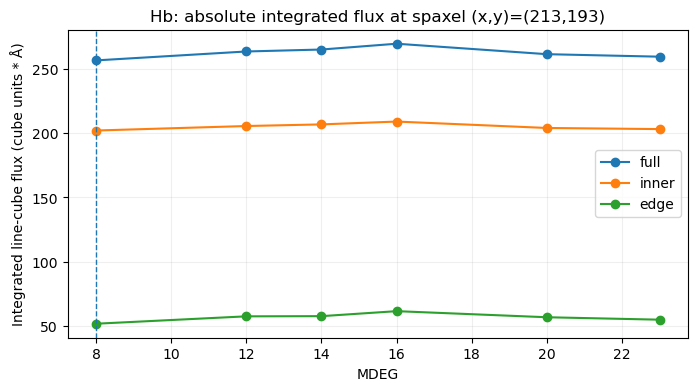

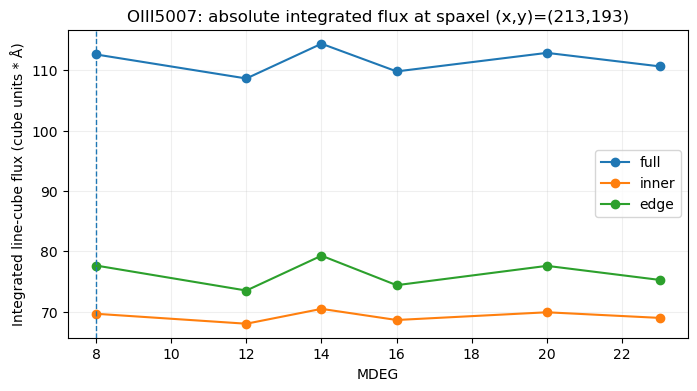

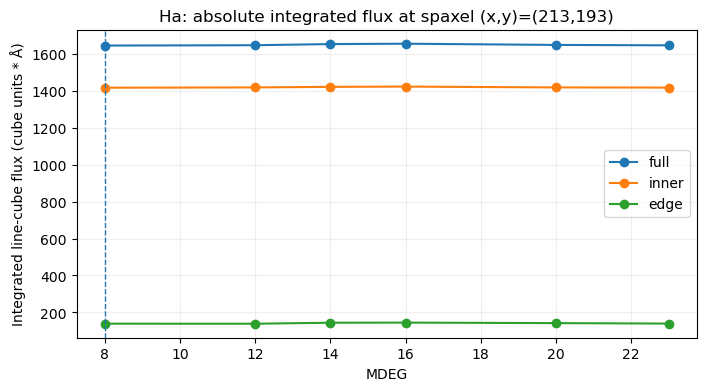

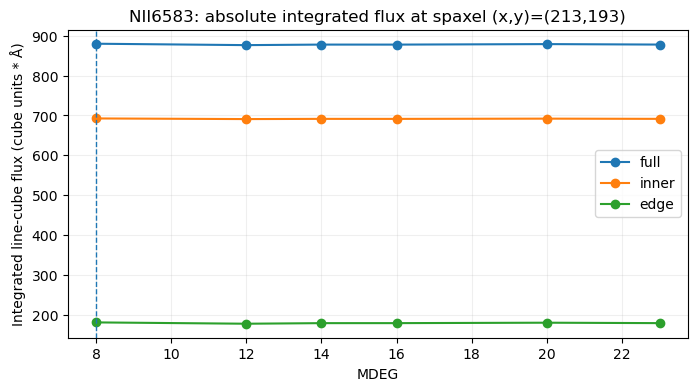

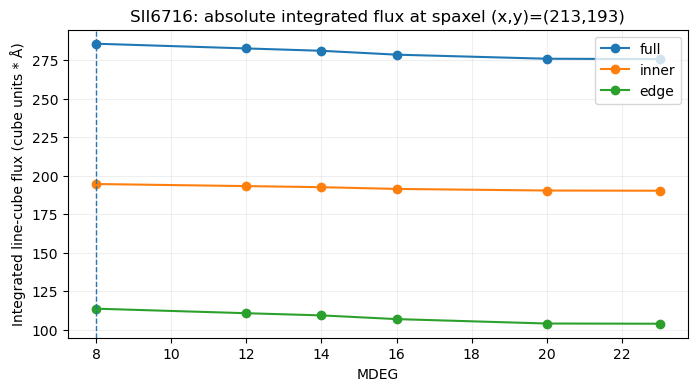

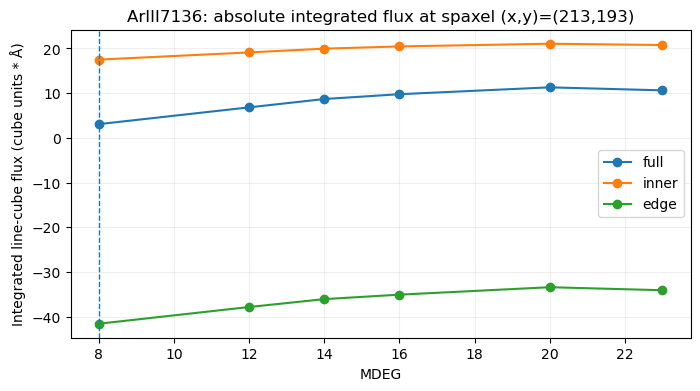

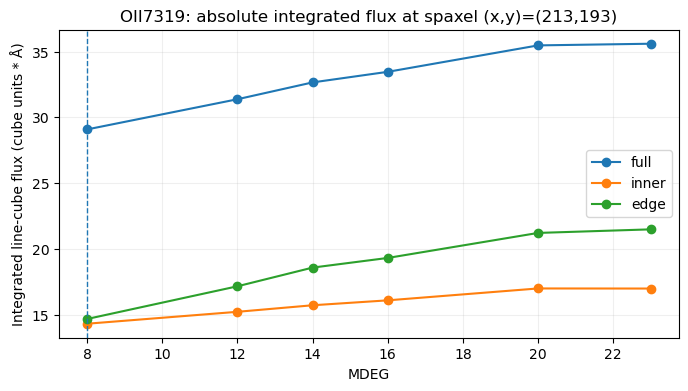

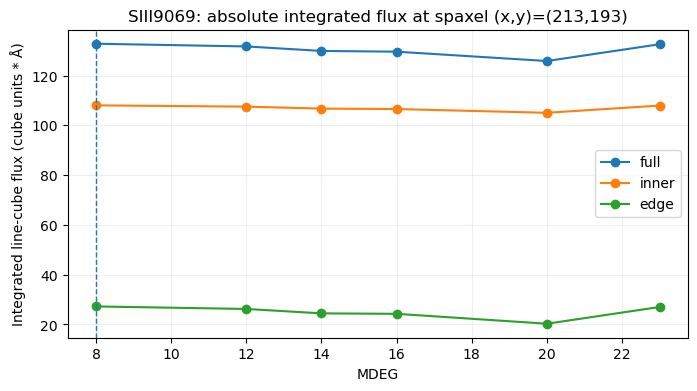

In [7]:
# ============================
# Cell 6: Plot absolute integrated line-cube flux vs MDEG
# ============================
# For each line:
# - x-axis: MDEG
# - y-axis: integrated flux from line cube at the target spaxel
# - show curves for full/inner/edge
#
# This answers: "Does increasing MDEG change the recovered integrated flux?"

def plot_abs_flux_per_line(df, line_name):
    sub = df[df["line"] == line_name].copy()
    sub = sub.sort_values("mdeg")

    plt.figure(figsize=(8,4))
    for region in ["full","inner","edge"]:
        s2 = sub[sub["region"] == region]
        plt.plot(s2["mdeg"], s2["F_linecube"], marker="o", label=region)

    plt.axvline(FID_MDEG, linestyle="--", linewidth=1)
    plt.xlabel("MDEG")
    plt.ylabel("Integrated line-cube flux (cube units * Å)")
    plt.title(f"{line_name}: absolute integrated flux at spaxel (x,y)=({x0},{y0})")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

for lname in LINES.keys():
    plot_abs_flux_per_line(df, lname)


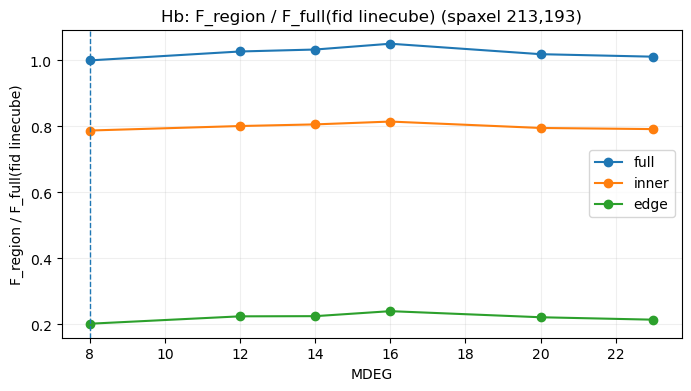

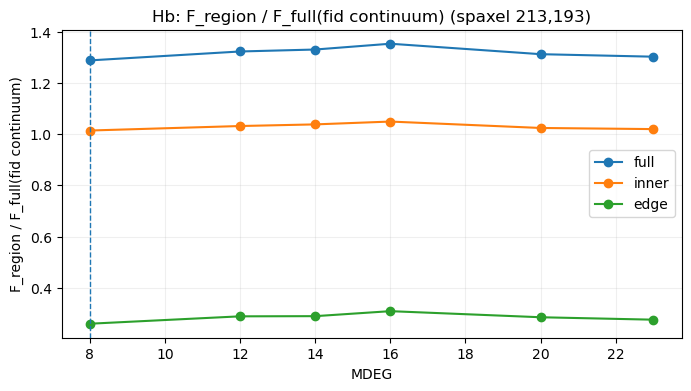

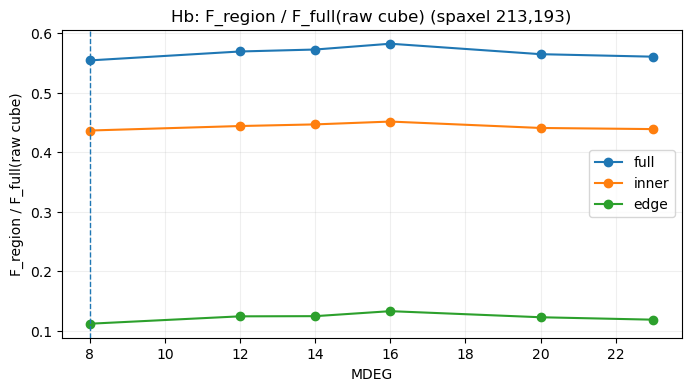

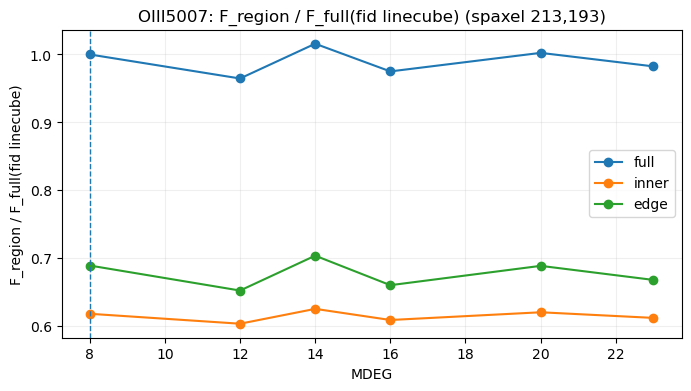

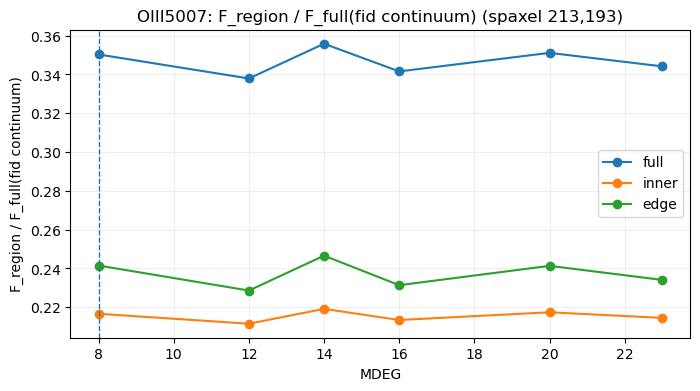

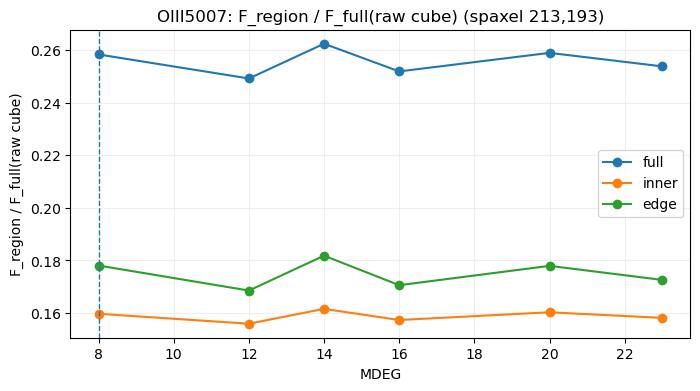

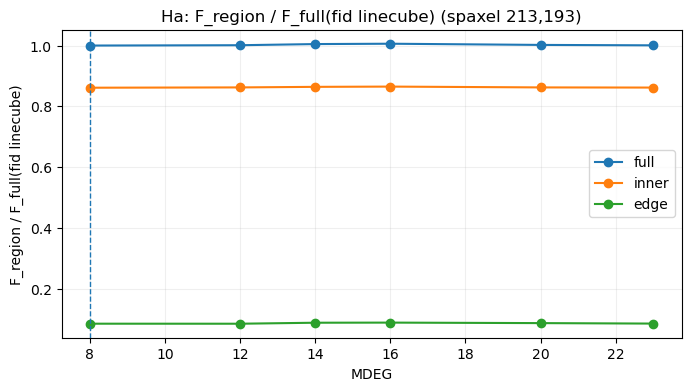

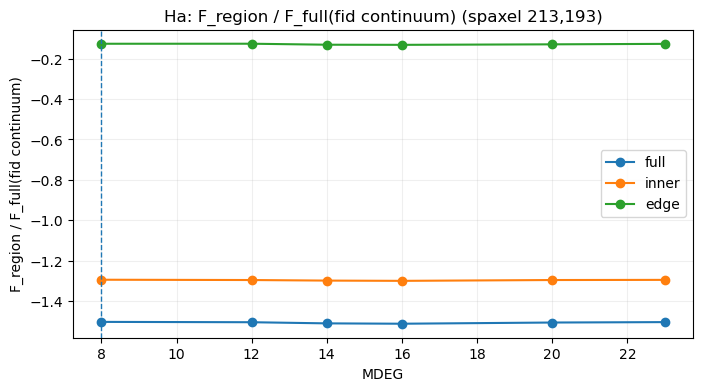

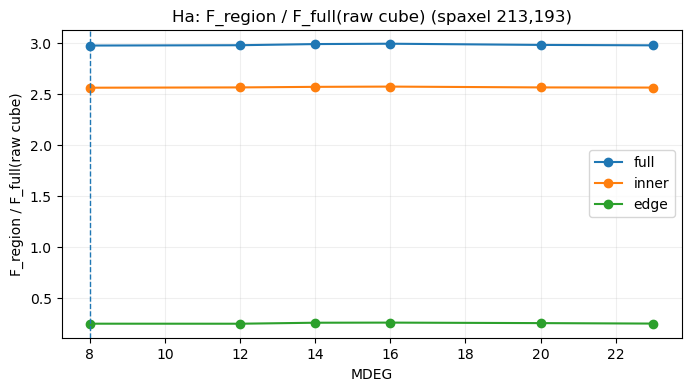

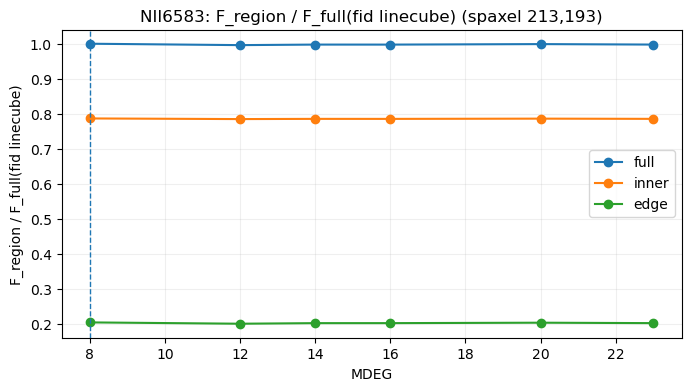

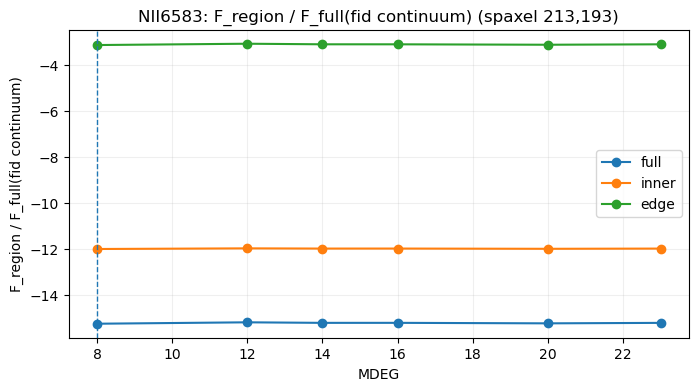

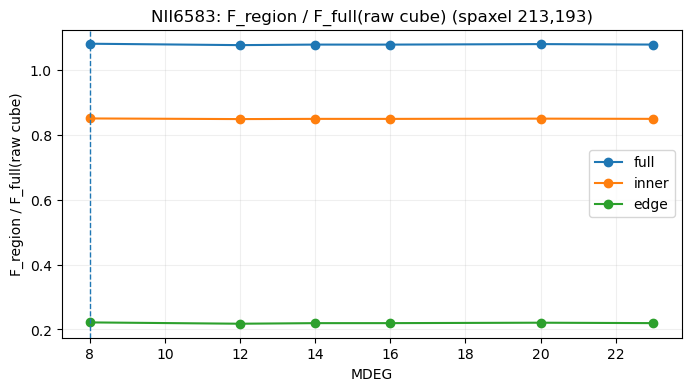

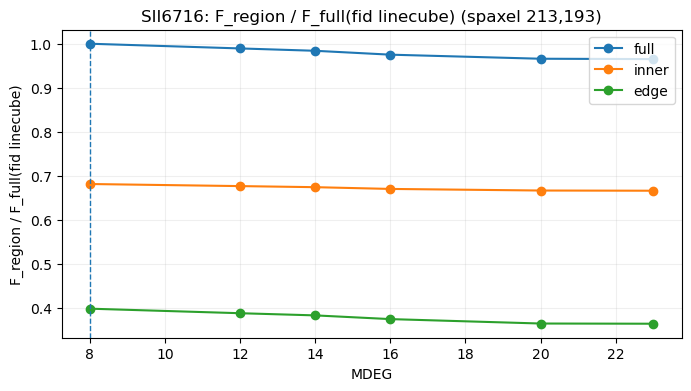

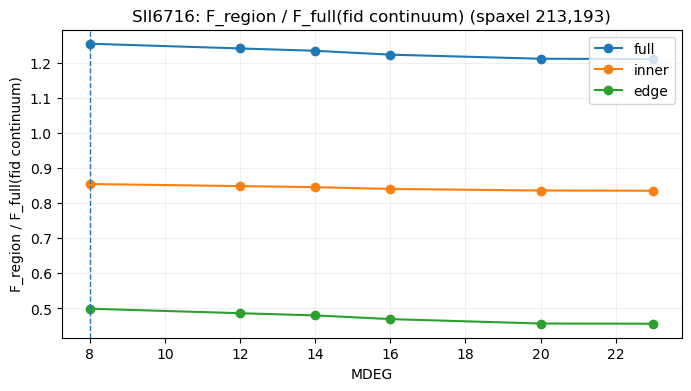

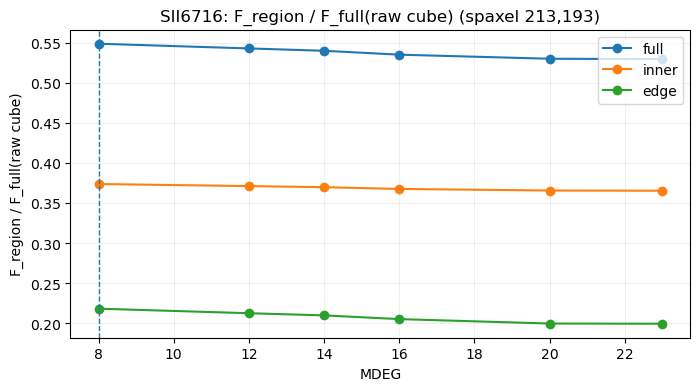

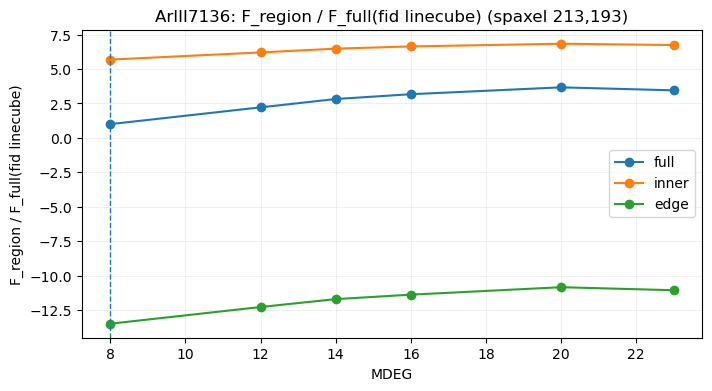

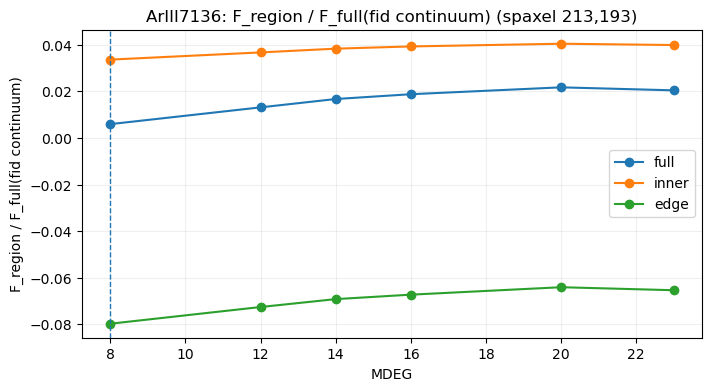

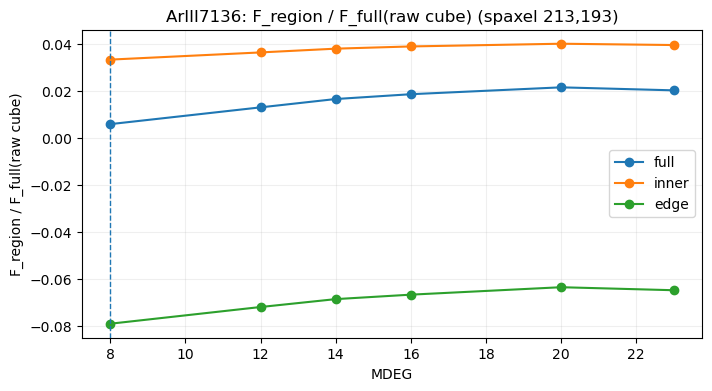

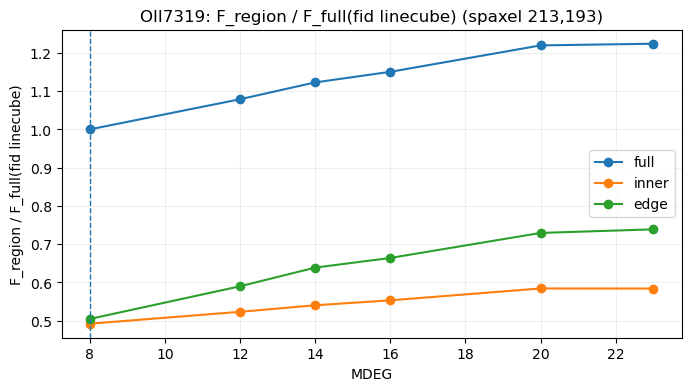

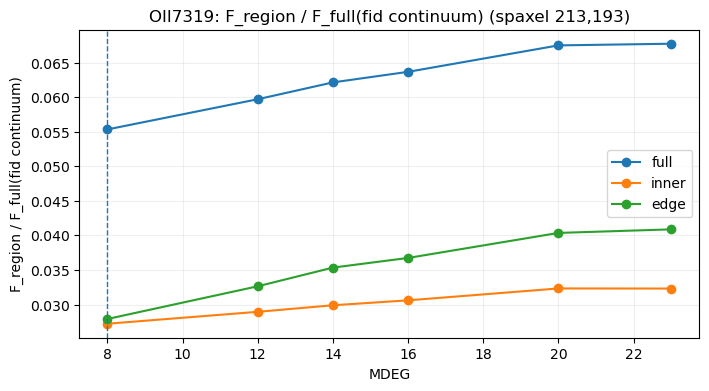

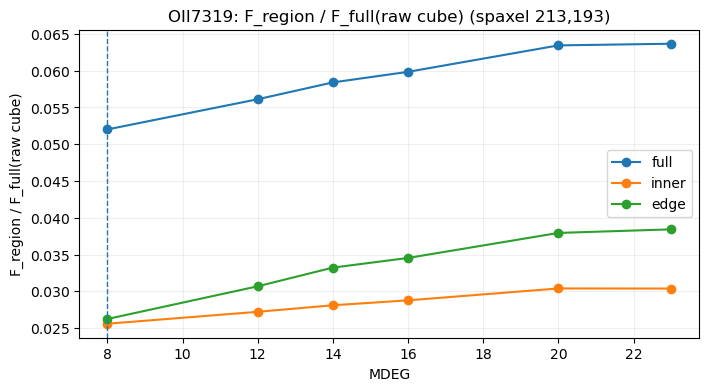

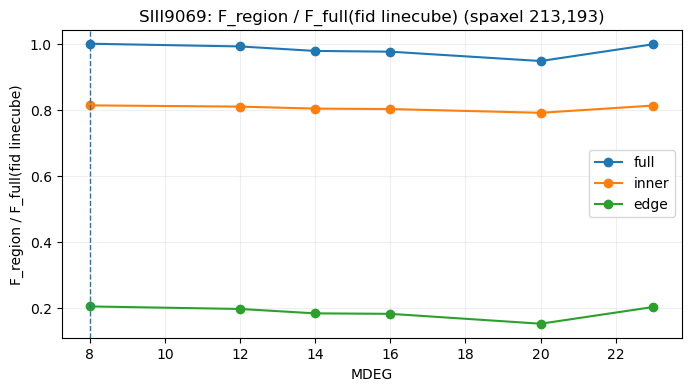

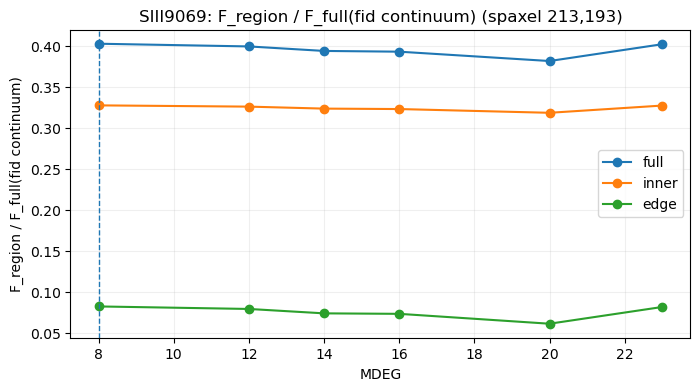

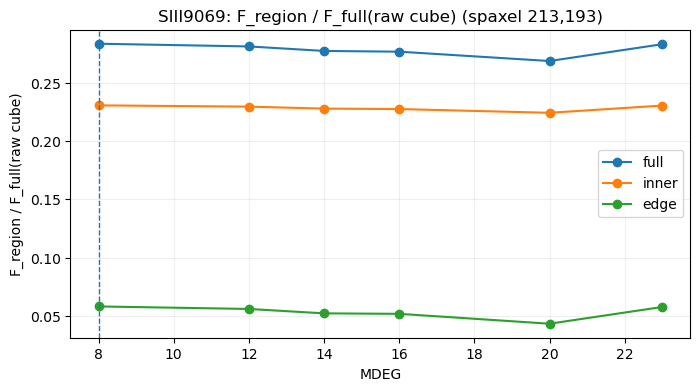

In [8]:
# ============================
# Cell 7: Plot requested fractions vs MDEG
# ============================
# For each line & each region, we plot:
# - F_region_mdeg / F_full_fid_linecube  (always available)
# - F_region_mdeg / F_full_fid_contcube  (if cont cube available)
# - F_region_mdeg / F_full_orig          (if orig cube available)

def plot_fractions(df, line_name, denom_col, ylabel):
    sub = df[df["line"] == line_name].copy()
    sub = sub.sort_values("mdeg")

    plt.figure(figsize=(8,4))
    for region in ["full","inner","edge"]:
        s2 = sub[sub["region"] == region]
        plt.plot(s2["mdeg"], s2[denom_col], marker="o", label=region)

    # plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.axvline(FID_MDEG, linestyle="--", linewidth=1)
    plt.xlabel("MDEG")
    plt.ylabel(ylabel)
    plt.title(f"{line_name}: {ylabel} (spaxel {x0},{y0})")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

for lname in LINES.keys():
    # always exists
    plot_fractions(df, lname, "frac_to_linefid", "F_region / F_full(fid linecube)")

    # only if cont exists
    if np.isfinite(df.loc[df["line"]==lname, "fid_cont_full"]).any():
        plot_fractions(df, lname, "frac_to_contfid", "F_region / F_full(fid continuum)")

    # only if orig exists
    if np.isfinite(df.loc[df["line"]==lname, "orig_full"]).any():
        plot_fractions(df, lname, "frac_to_rawfull", "F_region / F_full(raw cube)")


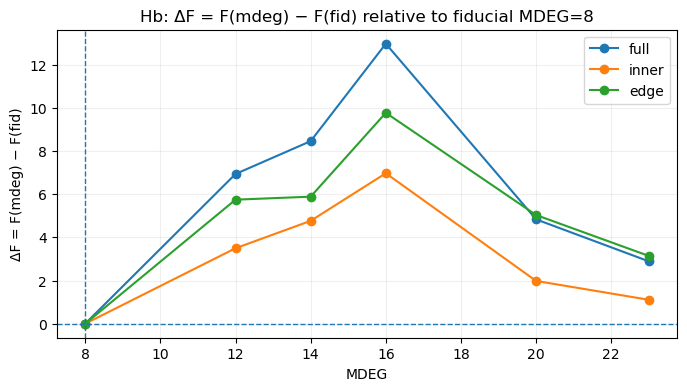

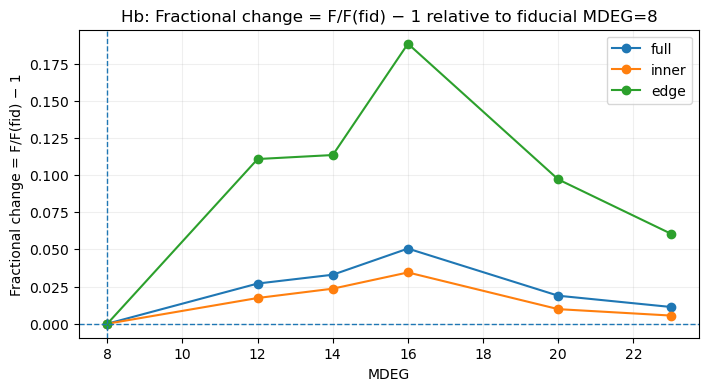

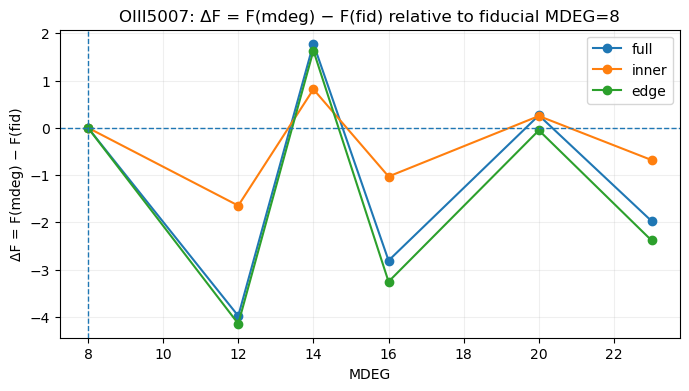

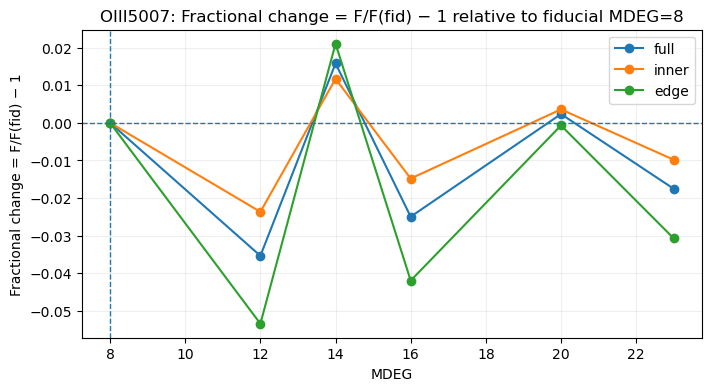

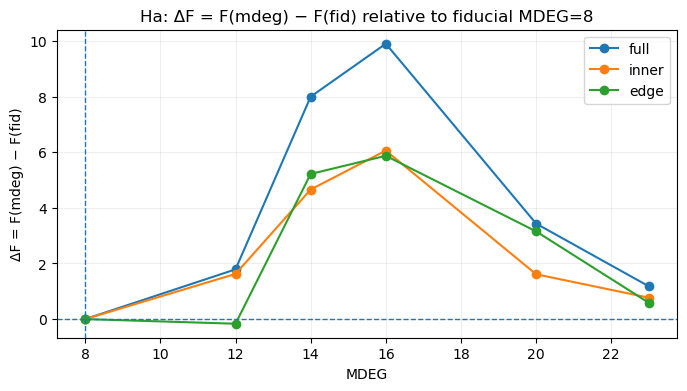

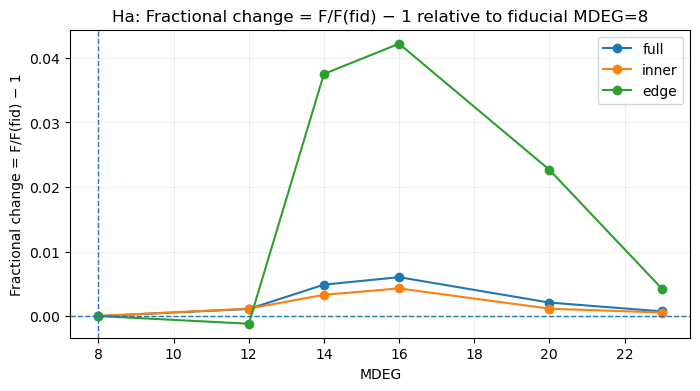

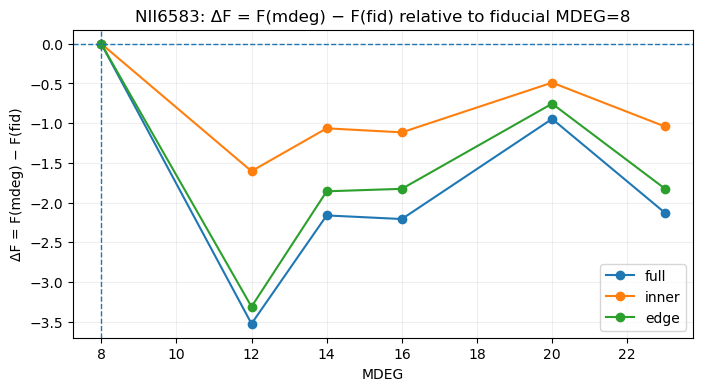

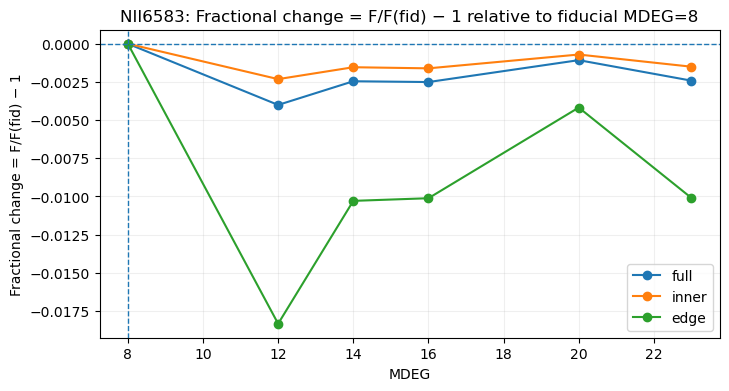

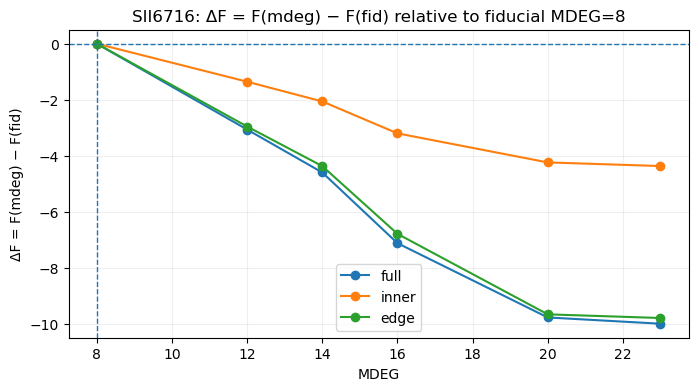

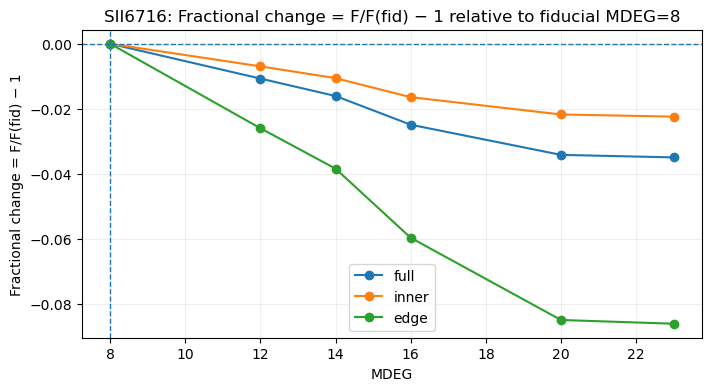

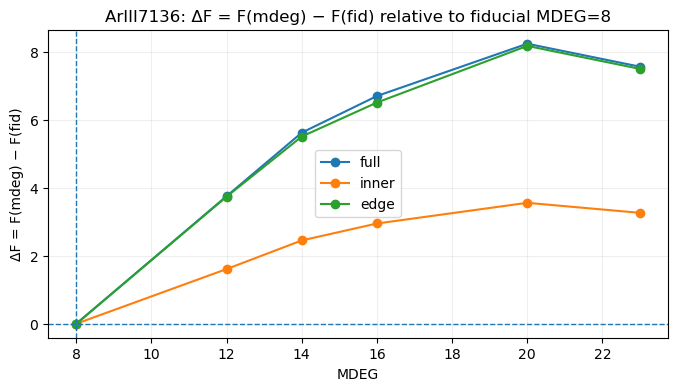

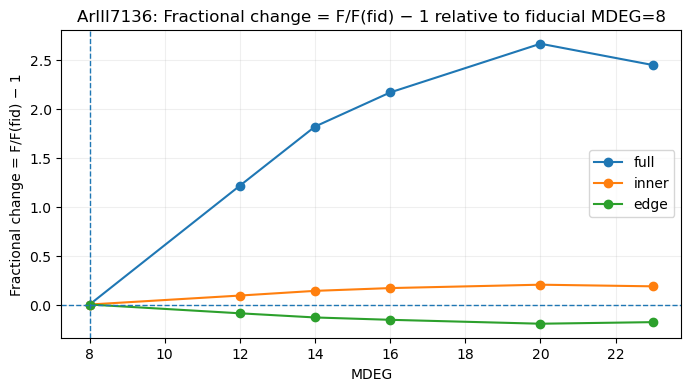

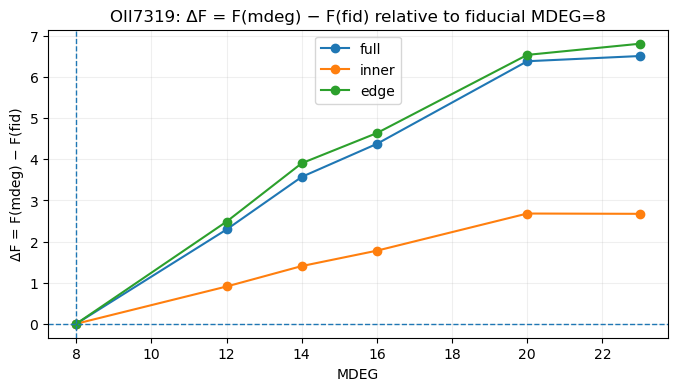

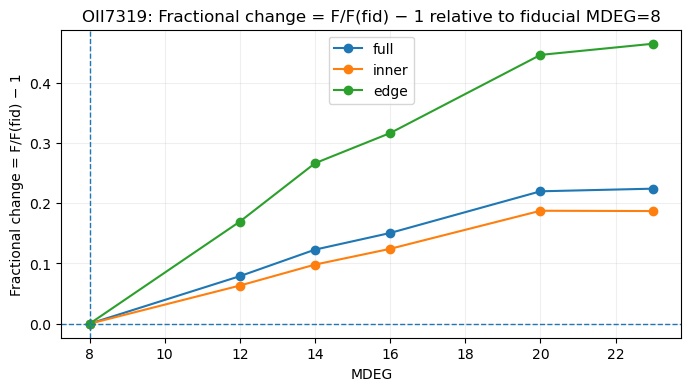

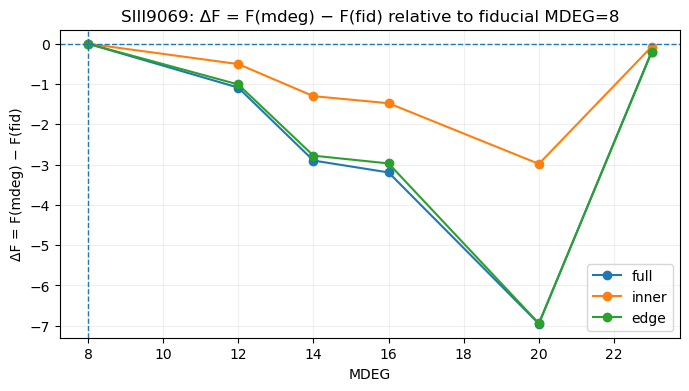

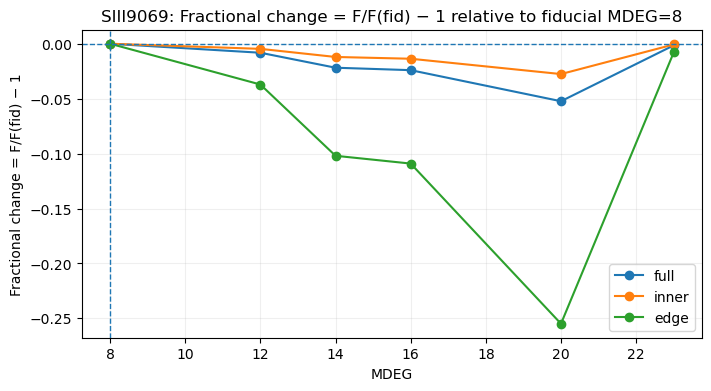

In [9]:
# ============================
# Cell 8: Differences vs fiducial (MDEG=8)
# ============================
# You requested "do subtraction between 8 and other MDEG":
# We compute for each line & region:
#   ΔF = F(mdeg) - F(fid=8)
#   frac_change = (F(mdeg)/F(fid=8)) - 1
#
# This is the cleanest way to see whether increasing MDEG produces systematic drift.

def add_deltas_vs_fid(df):
    out = df.copy()
    # Build a lookup table of fiducial flux per (line, region)
    fid = out[out["mdeg"] == FID_MDEG][["line","region","F_linecube"]].rename(columns={"F_linecube":"F_fid"})
    out = out.merge(fid, on=["line","region"], how="left")
    out["dF_vs_fid"] = out["F_linecube"] - out["F_fid"]
    out["frac_change_vs_fid"] = out["F_linecube"] / out["F_fid"] - 1.0
    return out

df2 = add_deltas_vs_fid(df)

def plot_delta(df2, line_name, col, ylabel):
    sub = df2[df2["line"] == line_name].copy().sort_values("mdeg")

    plt.figure(figsize=(8,4))
    for region in ["full","inner","edge"]:
        s2 = sub[sub["region"] == region]
        plt.plot(s2["mdeg"], s2[col], marker="o", label=region)

    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.axvline(FID_MDEG, linestyle="--", linewidth=1)
    plt.xlabel("MDEG")
    plt.ylabel(ylabel)
    plt.title(f"{line_name}: {ylabel} relative to fiducial MDEG={FID_MDEG}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

for lname in LINES.keys():
    plot_delta(df2, lname, "dF_vs_fid", "ΔF = F(mdeg) − F(fid)")
    plot_delta(df2, lname, "frac_change_vs_fid", "Fractional change = F/F(fid) − 1")


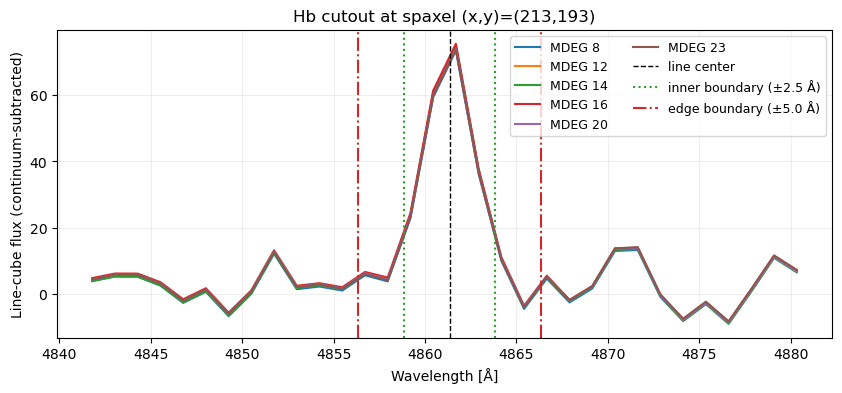

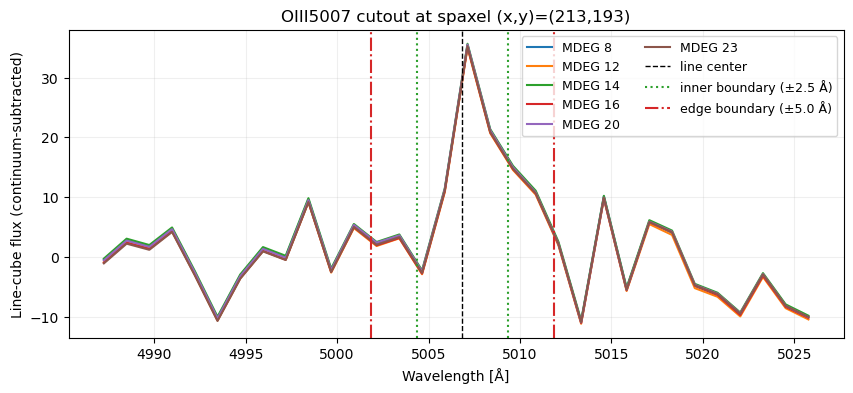

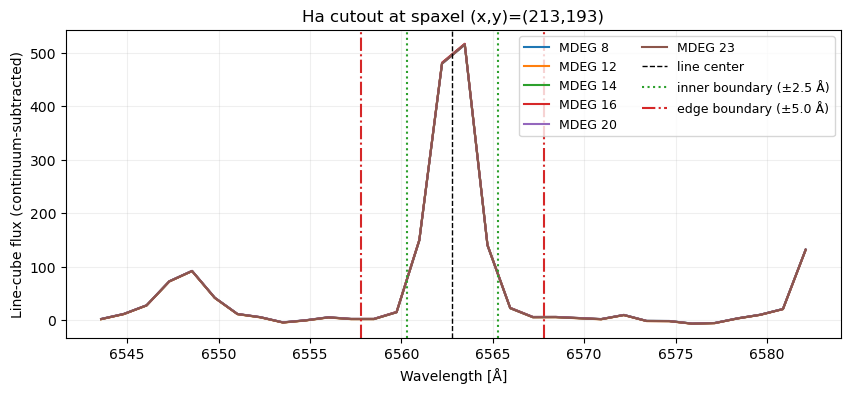

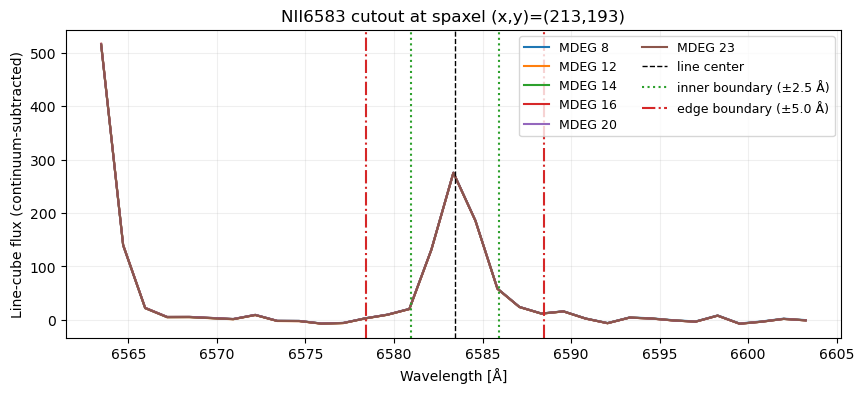

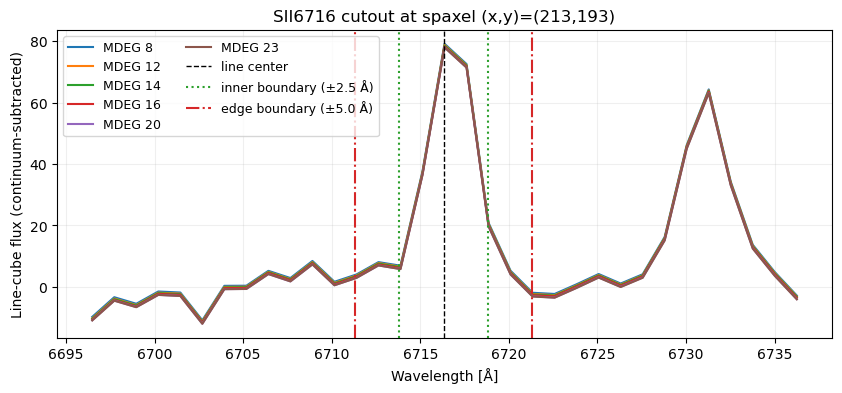

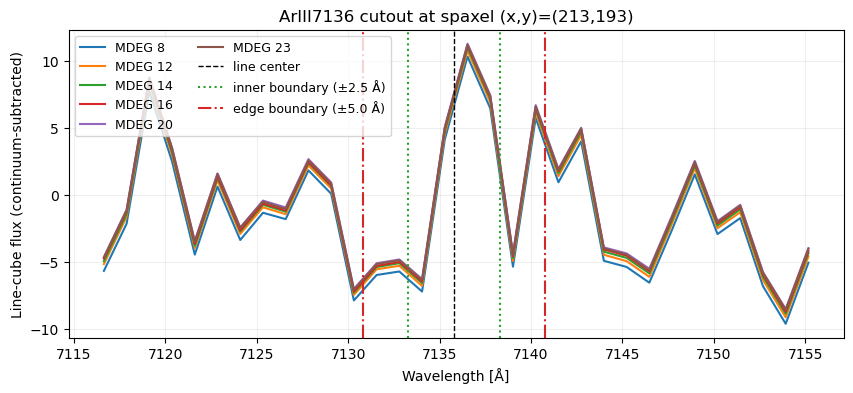

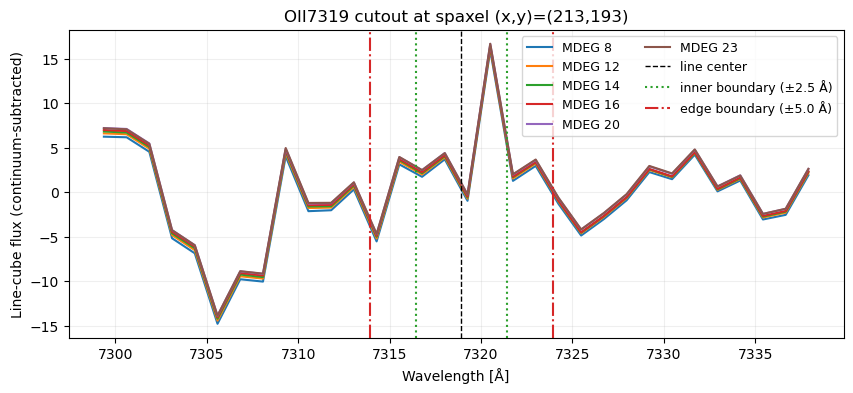

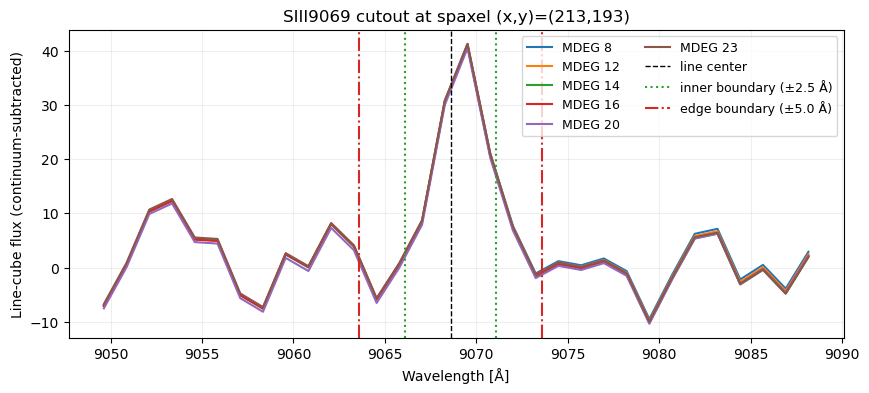

In [10]:
# ============================
# Cell 9 (Optional): Spectral cutouts around each line for visual sanity
# ============================
# This helps confirm whether the "edge" flux is coming from real wings
# or from baseline / skyline residual structure.
#
# For each line: plot line-cube spectrum in [λ0-20, λ0+20] for all MDEGs.

def plot_cutout(line_name, halfwidth_plot=20.0):
    l0 = LINES[line_name]
    m = (wave >= l0 - halfwidth_plot) & (wave <= l0 + halfwidth_plot)
    inner_left, inner_right = l0 - HALF_INNER, l0 + HALF_INNER
    full_left, full_right = l0 - HALF_FULL, l0 + HALF_FULL

    plt.figure(figsize=(10,4))
    for mdeg in available_mdegs:
        plt.plot(wave[m], line_spec[mdeg][m], label=f"MDEG {mdeg}")
    plt.axvline(l0, linestyle="--", linewidth=1, color="black", label="line center")
    plt.axvline(inner_left, linestyle=":", linewidth=1.5, color="tab:green", label=f"inner boundary (±{HALF_INNER:.1f} Å)")
    plt.axvline(inner_right, linestyle=":", linewidth=1.5, color="tab:green")
    plt.axvline(full_left, linestyle="-.", linewidth=1.5, color="tab:red", label=f"edge boundary (±{HALF_FULL:.1f} Å)")
    plt.axvline(full_right, linestyle="-.", linewidth=1.5, color="tab:red")
    plt.xlabel("Wavelength [Å]")
    plt.ylabel("Line-cube flux (continuum-subtracted)")
    plt.title(f"{line_name} cutout at spaxel (x,y)=({x0},{y0})")
    plt.legend(ncol=2, fontsize=9)
    plt.grid(alpha=0.2)
    plt.show()

for lname in LINES.keys():
    plot_cutout(lname, halfwidth_plot=20.0)
